In [1]:
import utils_inverse
%load_ext autoreload
%autoreload 2

# Supplemental experiments to test sensitivity of optimization algorithm

## 1. Generate initial parameters, test backpropagation, and create baseline emulator

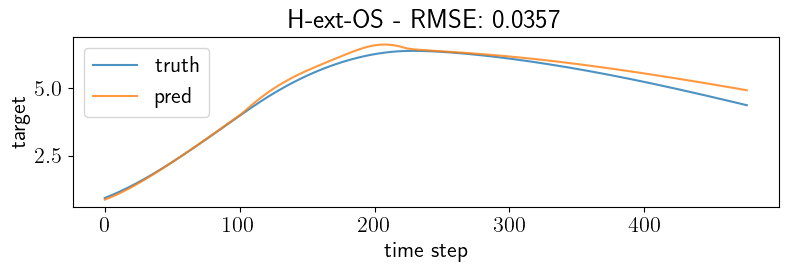

Getting gradient for historical...
	||grad BC||: 0.0
	||grad CH4||: 0.0
	||grad CO2||: 0.00019439701281953603
	||grad N2O||: 0.0
	||grad Sulfur||: 0.0


In [2]:
# Required to generate baseline parameters
agents        = ['CO2']       # Forcing agents included in temperatutre simulations
active_agents = ("CO2")       # Forcing agents with active gradients (can differ from above)
hidden_sizes  = [16]          # Dimension of neural network emulator
idx_demo      = 1             # Index of scenario to plot
test_scen     = 'historical'  # Scenario to test backpropagation; gradient printed wrt this scenario
verbose       = False         # Flag to print RMSE values for test

# Generate initial parameters and test backpropagation
params0, emis_dict_train_JAX = utils_inverse.generate_init_params_and_train_data(agents,
                                                                                 active_agents,
                                                                                 test_scen,
                                                                                 hidden_sizes=hidden_sizes,
                                                                                 idx_demo=idx_demo,
                                                                                 verbose=verbose)

In [3]:
# Generate data for emulator evaluation
(eval_sets,
emis_dict_tier1_JAX,
emis_dict_tier2_JAX,
emis_dict_DECK_JAX,
emis_dict_CS3_JAX,
emis_dict_all_JAX) = utils_inverse.generate_eval_data(agents, CS3=True, DAMIP=False, GeoMIP=False)

In [4]:
# Baseline parameters
save_path = None  # Location to save baseline data
verbose   = False # Flag to print NRMSE values from the baseline emulator

# Create baseline emulator
baseline_results, baseline_pred_delT, ground_truth_delT = utils_inverse.generate_and_eval_baseline_emulator(emis_dict_tier1_JAX,
                                                                                                            eval_sets, save_path=save_path,
                                                                                                            verbose=verbose, hidden_sizes=hidden_sizes)

## 2. Test optimization sensitivity to initial condition
Here, we test the optimized emulator's performance relative to the baseline when initialized from constant, ramp, gaussian, and sinusoidal initial conditions.

In [5]:
## Create validation data; this is the optimization target
emis_dict_valid = emis_dict_all_JAX.copy()  # Evaluate performance over all scenarios

## Optimization parameters held constant for these tests
num_updates       = 1000          # Number of optimization iterations
step_size         = 1e3           # Step size for optimizer, gradients are typically very small
momentum          = 0.9           # Momentum decay rate
nesterov          = True          # Flag to use nesterov momentum in optimization
K_inner           = 400           # Number of gradient descent steps during training
lr_inner          = 5e-2          # Learning rate during training
wd_inner          = 1e-2          # Weight decay (regularization) for training
active_agents     = ("CO2")       # Forcing agents to optmize over (may differ from "agents" defined previously)
T                 = 751           # Length of optimized time series
filter_hist       = False          # Flag to not include historical data in the optimization
smoothness_weight = 1e-5          # Penalty to prevent sharp gradients in the resulting time series

## Parameters for saving output data
checkpoint_every    = 50    # How often to save snapshots of the optimization
resume_if_exists    = False  # Flag to continue optimization from saved checkpoint, overwrites existing data if False
preds_every         = 50    # How often to save emulator temperature predictions

In [6]:
## Parameters modified for each test
results_dict_IC    = {}                            # Dictionary to store results
init_cond_list  = ['constant','ramp','gaussian','sine']    # Emissions initial condition

## Iterate over initial conditions
for init_cond in init_cond_list:
    print(f'Optimizing over {init_cond} IC')

    # Location of save data changes for each IC
    checkpoint_path = f"data/SI_results/sensitivity_initial_condition/inverse_{init_cond}_co2_only.pkl" # Location to save data

    ## Run optimization algorithm
    results_dict_IC[init_cond] = utils_inverse.optimize_emissions_inverse(
        emis_dict=emis_dict_valid,
        params0=params0,
        num_updates=num_updates,
        step_size=step_size,
        momentum=momentum,
        nesterov=nesterov,
        K_inner=K_inner,
        lr_inner=lr_inner,
        wd_inner=wd_inner,
        active_agents=active_agents,
        init_cond=init_cond,
        T=T,
        filter_hist=filter_hist,
        checkpoint_path=checkpoint_path,
        checkpoint_every=checkpoint_every,
        resume_if_exists=resume_if_exists,
        preds_every=preds_every,
    )

Optimizing over constant IC
Overwriting save data...
Optimizing over ramp IC
Overwriting save data...
Optimizing over gaussian IC
Overwriting save data...
Optimizing over sine IC
Overwriting save data...


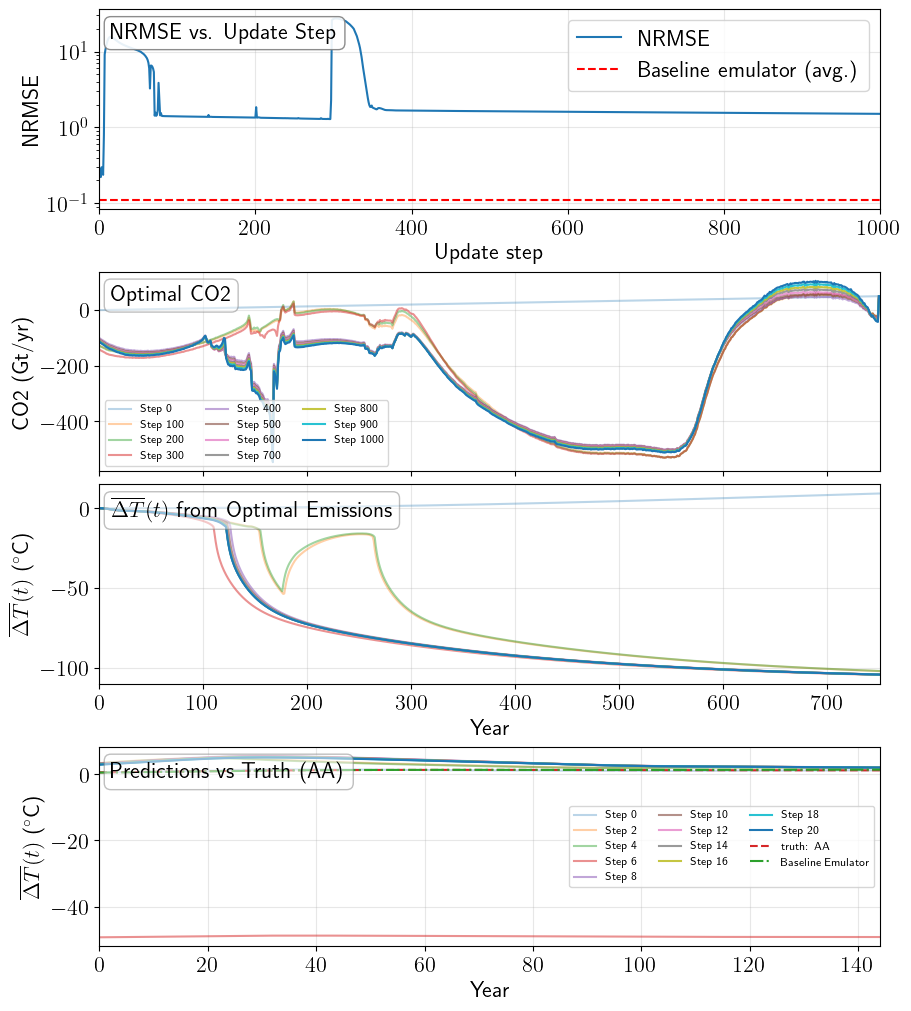

In [10]:
# Optional: plot results of optimization
## Plotting parameters
init_cond_plot  = 'ramp'    # IC to plot
baseline_test   = 'All'     # Evaluation set to plot
predict_plot    = 'AA'      # Individual scenario to plot predictions

utils_inverse.plot_inverse_results(
    results_dict_IC[init_cond_plot],
    baseline_results[baseline_test]['mean'],
    active_agents=('CO2',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_pred_delT[baseline_test][predict_plot]
)

## 3. Test optimization sensitivity to emulator architecture
Here, we test the optimized emulator's performance relative to the baseline when using neural networks of different sizes. We consider the following sizes: [8], [16], [32], and [16, 16], where the number of elements in the array indicates the depth of the network. Note that the baseline emulator must also be trained with the same size network as the optimized emulator to ensure a fair comparison.

In [ ]:
## Parameters held constant while architecture changes
# Required to generate baseline parameters
agents        = ['CO2']       # Forcing agents included in temperatutre simulations
active_agents = ("CO2")       # Forcing agents with active gradients (can differ from above)
idx_demo      = 1             # Index of scenario to plot
test_scen     = 'historical'  # Scenario to test backpropagation; gradient printed wrt this scenario
verbose       = False         # Flag to print RMSE values for test

In [ ]:
# Modify dimension of neural network emulator
results_dict_arch = {}
hidden_sizes_list, hidden_labels = [[8], [16], [32], [16,16]], ['8','16','32','16, 16']
for hidden_sizes in hidden_sizes_list:
  # Generate initial parameters and test backpropagation
  params0, emis_dict_train_JAX = utils_inverse.generate_init_params_and_train_data(agents,
                                                                                  active_agents,
                                                                                  test_scen,
                                                                                  hidden_sizes=hidden_sizes,
                                                                                  idx_demo=idx_demo,
                                                                                  verbose=verbose)

## 4. Test optimization sensitivity to emulator features